<a href="https://colab.research.google.com/github/jane-rusakova/python_for_hw_tasks/blob/main/%D0%A4%D1%96%D0%BD%D0%B0%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D0%BF%D1%80%D0%BE%D1%94%D0%BA%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Вступ

В еру технологій та непередбачуваних обставин (ковід, війа) онлайн-платформи навчання стали важливою частиною сучасної освіти, надаючи користувачам доступ до великої кількості курсів, навчальних матеріалів та програм для розвитку навичок та підвищення кваліфікацій. Розуміння поведінки користувачів на таких платформах є важливим для покращення якості навчального процесу, підвищення рівня завершення курсів та загальної задоволеності користувачів.

Метою цього проєкту є аналіз даних користувачів онлайн-платформ навчання для виявлення основних факторів, які впливають на рівень завершення курсів, задоволеність користувачів та їхню залученість до навчання.

У межах проєкту було використано декілька інструментів аналізу даних, зокрема **Python (pandas, matplotlib, seaborn)** для дослідження та візуалізації даних, **SQL** для виконання аналітичних запитів, **Google Sheets** для побудови зведених таблиць і базових графіків, а також **Power BI** для створення інтерактивного аналітичного дашборду.

Крім того, було застосовано базову модель **машинного навчання**, яка дозволяє дослідити можливість прогнозування рівня задоволеності користувачів на основі їхніх характеристик та поведінки на платформі.

Результати аналізу дозволяють краще зрозуміти, як різні фактори — такі як навчальна платформа, вікова група користувачів, тип навчального контенту та кількість годин навчання — впливають на ефективність онлайн-навчання.

## Опис датасету

У цьому проєкті використовується датасет, що містить інформацію про користувачів онлайн-платформ навчання та їхню поведінку під час проходження курсів. (інформацію брала на сайті https://www.kaggle.com/datasets)

Кожен рядок у датасеті представляє окремого користувача та містить інформацію про його характеристики, навчальні вподобання та рівень залученості до навчання.

Датасет містить такі основні змінні:

- **user_id** — унікальний ідентифікатор користувача
- **age_group** — вікова група користувача
- **primary_platform** — основна платформа онлайн-навчання, яку використовує користувач
- **learning_purpose** — мета навчання (наприклад: професійний розвиток, академічне навчання, особистий розвиток)
- **content_type_preference** — тип навчального контенту, якому користувач надає перевагу (відео, текстовий або змішаний формат)
- **hours_per_week** — кількість годин навчання на тиждень
- **completion_rate_percent** — відсоток завершення курсів
- **satisfaction_score** — рівень задоволеності користувача платформою

Усього датасет містить **420 записів**, що дозволяє провести базовий аналіз поведінки користувачів онлайн-навчальних платформ та дослідити взаємозв’язки між різними характеристиками користувачів і результатами навчання.

Так як мені вдалось знайти не дуже об'ємний датасет (420 записів), але мені дуже блзька тема навчальних платформ, бо це зараз частина моєї роботи, вирішила все ж таки присвітити фінальний проєкт цій темі і створити ще одну таблицю і таким чином розширити дані

In [32]:
import pandas as pd

df = pd.read_csv("online_learning_platform_usage_dataset.csv")

df.head()

,user_id,age_group,role,primary_platform,learning_device,hours_per_week,learning_purpose,content_type_preference,completion_rate_percent,satisfaction_score
0,1,35-44,Working Professional,edX,Laptop,10,Career Growth,Text,34,5
1,2,45+,Other,edX,Mobile,12,Career Growth,Text,17,3
2,3,25-34,Freelancer,Skillshare,Desktop,2,Academic,Text,67,9
3,4,45+,Working Professional,Udemy,Mobile,3,Career Growth,Mixed,25,5
4,5,45+,Working Professional,Khan Academy,Mobile,10,Hobby,Video,81,5


In [33]:
df.shape

(420, 10)

In [34]:
import numpy as np

np.random.seed(42)

df["course_id"] = np.random.randint(1,9,size=len(df))

df.head()

,user_id,age_group,role,primary_platform,learning_device,hours_per_week,learning_purpose,content_type_preference,completion_rate_percent,satisfaction_score,course_id
0,1,35-44,Working Professional,edX,Laptop,10,Career Growth,Text,34,5,7
1,2,45+,Other,edX,Mobile,12,Career Growth,Text,17,3,4
2,3,25-34,Freelancer,Skillshare,Desktop,2,Academic,Text,67,9,5
3,4,45+,Working Professional,Udemy,Mobile,3,Career Growth,Mixed,25,5,7
4,5,45+,Working Professional,Khan Academy,Mobile,10,Hobby,Video,81,5,3


In [35]:
df.columns

Index(['user_id', 'age_group', 'role', 'primary_platform', 'learning_device',
       'hours_per_week', 'learning_purpose', 'content_type_preference',
       'completion_rate_percent', 'satisfaction_score', 'course_id'],
      dtype='object')

In [36]:
courses = pd.DataFrame({
    "course_id":[1,2,3,4,5,6,7,8],
    "course_name":[
        "Python for Beginners",
        "Data Analysis with Python",
        "Business Analytics",
        "Digital Marketing Basics",
        "Machine Learning",
        "SQL Fundamentals",
        "Project Management",
        "UX Design"
    ],
    "category":[
        "Programming",
        "Data Science",
        "Business",
        "Marketing",
        "Data Science",
        "Programming",
        "Business",
        "Design"
    ],
    "difficulty":[
        "Beginner",
        "Intermediate",
        "Beginner",
        "Beginner",
        "Advanced",
        "Beginner",
        "Intermediate",
        "Beginner"
    ],
    "duration_hours":[10,20,12,8,25,15,14,10],
    "platform":[
        "Coursera",
        "Coursera",
        "edX",
        "Udemy",
        "Coursera",
        "Udemy",
        "edX",
        "Udemy"
    ]
})

courses

,course_id,course_name,category,difficulty,duration_hours,platform
0,1,Python for Beginners,Programming,Beginner,10,Coursera
1,2,Data Analysis with Python,Data Science,Intermediate,20,Coursera
2,3,Business Analytics,Business,Beginner,12,edX
3,4,Digital Marketing Basics,Marketing,Beginner,8,Udemy
4,5,Machine Learning,Data Science,Advanced,25,Coursera
5,6,SQL Fundamentals,Programming,Beginner,15,Udemy
6,7,Project Management,Business,Intermediate,14,edX
7,8,UX Design,Design,Beginner,10,Udemy


In [37]:
df.to_csv("users_learning_with_courses.csv", index=False)
courses.to_csv("courses.csv", index=False)

Пункт 2

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   user_id                  420 non-null    int64 
 1   age_group                420 non-null    object
 2   role                     420 non-null    object
 3   primary_platform         420 non-null    object
 4   learning_device          420 non-null    object
 5   hours_per_week           420 non-null    int64 
 6   learning_purpose         420 non-null    object
 7   content_type_preference  420 non-null    object
 8   completion_rate_percent  420 non-null    int64 
 9   satisfaction_score       420 non-null    int64 
 10  course_id                420 non-null    int64 
dtypes: int64(5), object(6)
memory usage: 36.2+ KB


In [39]:
df.isnull().sum()

,0
user_id,0
age_group,0
role,0
primary_platform,0
learning_device,0
hours_per_week,0
learning_purpose,0
content_type_preference,0
completion_rate_percent,0
satisfaction_score,0


In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df.describe()

,user_id,hours_per_week,completion_rate_percent,satisfaction_score,course_id
count,420.000000,420.000000,420.000000,420.000000,420.000000
mean,210.500000,10.476190,53.935714,5.228571,4.519048
std,121.387808,5.708253,26.638357,2.814918,2.345385
min,1.000000,1.000000,10.000000,1.000000,1.000000
25%,105.750000,5.750000,30.000000,3.000000,3.000000
50%,210.500000,11.000000,54.000000,5.000000,4.000000
75%,315.250000,15.000000,77.250000,8.000000,7.000000
max,420.000000,20.000000,100.000000,10.000000,8.000000


## Попередній огляд та перевірка даних

На цьому етапі було виконано первинний огляд набору даних з метою перевірки його структури, якості та придатності для подальшого аналізу.

### Виконані кроки

Було проведено такі перевірки:

- перевірено структуру датасету та типи даних за допомогою `df.info()`;
- перевірено наявність пропущених значень за допомогою `df.isnull().sum()`;
- перевірено наявність дублікатів за допомогою `df.duplicated().sum()`;
- отримано базову описову статистику числових змінних за допомогою `df.describe()`.

### Результати перевірки

- датасет містить **420 записів** та **11 колонок**;
- **пропущені значення відсутні**;
- **дублікати не виявлені**;
- числові змінні (`hours_per_week`, `completion_rate_percent`, `satisfaction_score`) мають коректні значення.

### Висновок

Отже, набір даних є достатньо чистим та придатним для подальшого **дослідницького аналізу даних (EDA)**.

Питання 1

Який середній рівень завершення курсів (completion rate) серед користувачів платформи?

In [42]:
df["completion_rate_percent"].mean()

np.float64(53.93571428571428)

### Аналіз середнього рівня завершення курсів

Отриманий результат становить **53,94%**, що означає, що в середньому користувачі проходять трохи більше половини навчальних курсів.

Це може свідчити про помірний рівень залученості користувачів до навчального процесу. Водночас результат показує, що значна частина курсів залишається незавершеною, що може бути пов'язано з різними факторами, такими як складність матеріалу, недостатня мотивація або обмежений час для навчання.

---

Питання 2

Чи впливає кількість годин навчання на тиждень (hours_per_week) на рівень завершення курсу?

In [43]:
df[["hours_per_week","completion_rate_percent"]].corr()

,hours_per_week,completion_rate_percent
hours_per_week,1.000000,-0.033324
completion_rate_percent,-0.033324,1.000000


### Аналіз зв'язку між часом навчання та рівнем завершення курсу

Було проаналізовано кореляцію між кількістю годин навчання на тиждень (`hours_per_week`) та рівнем завершення курсу (`completion_rate_percent`).

Отримане значення коефіцієнта кореляції становить **-0.03**, що є дуже близьким до нуля.

Це свідчить про те, що **суттєвого зв'язку між кількістю годин навчання та рівнем завершення курсу не виявлено**.

Тобто, користувачі, які витрачають більше часу на навчання протягом тижня, не обов'язково мають вищий рівень завершення курсу.

Це може свідчити про те, що на успішність навчання можуть більше впливати інші фактори, такі як тип контенту, складність курсу або мотивація користувача.

---

Питання 3

Чи відрізняється рівень завершення курсів між віковими групами?

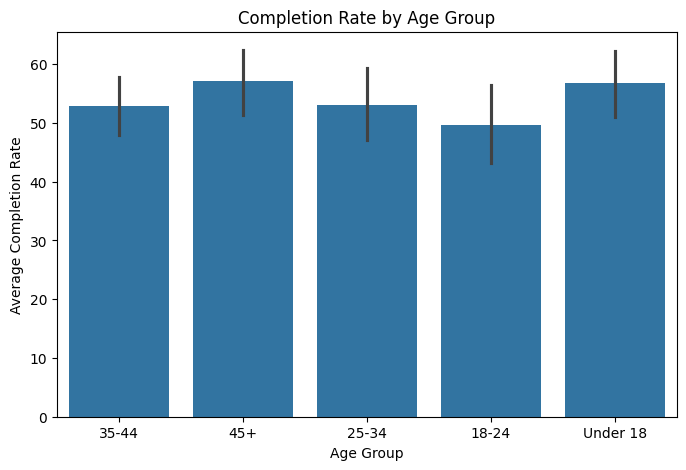

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.barplot(data=df, x="age_group", y="completion_rate_percent")

plt.title("Completion Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Completion Rate")

plt.show()

### Рівень завершення курсів за віковими групами

За результатами аналізу можна побачити, що рівень завершення курсів дещо відрізняється між віковими групами.

Найвищий середній рівень завершення спостерігається серед користувачів вікової групи **45+** та **Under 18**.  
Найнижчий показник має група **18–24**.

Водночас різниця між групами не є дуже значною, що може свідчити про те, що **вік не є основним фактором, який впливає на успішність проходження курсів**.

---

Питання 4

Чи відрізняється рівень завершення курсів залежно від платформи навчання?

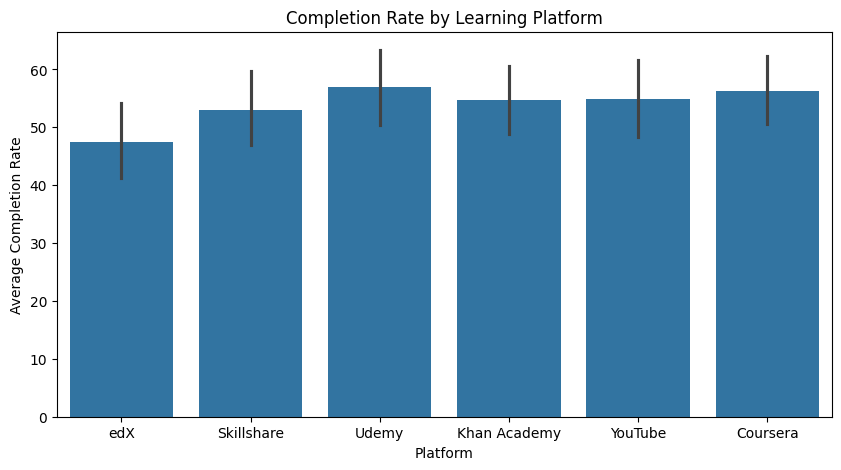

In [45]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="primary_platform", y="completion_rate_percent")

plt.title("Completion Rate by Learning Platform")
plt.xlabel("Platform")
plt.ylabel("Average Completion Rate")

plt.show()

### Рівень завершення курсів залежно від платформи навчання

Аналіз показує, що рівень завершення курсів дещо відрізняється між різними платформами онлайн-навчання.

Найвищий середній показник завершення курсів спостерігається на платформах **Udemy** та **Coursera**, що може свідчити про більш ефективну структуру курсів або кращу залученість користувачів.

Найнижчий рівень завершення курсів спостерігаємо на платформі **edX**.

Також видно, що різниця між платформами не є дуже значною, тому можна припустити, що на рівень завершення курсів впливають не лише особливості платформи, а й інші фактори, наприклад тип контенту або складність курсів.

---

Питання 5

Скільки годин на тиждень у середньому користувачі витрачають на навчання?

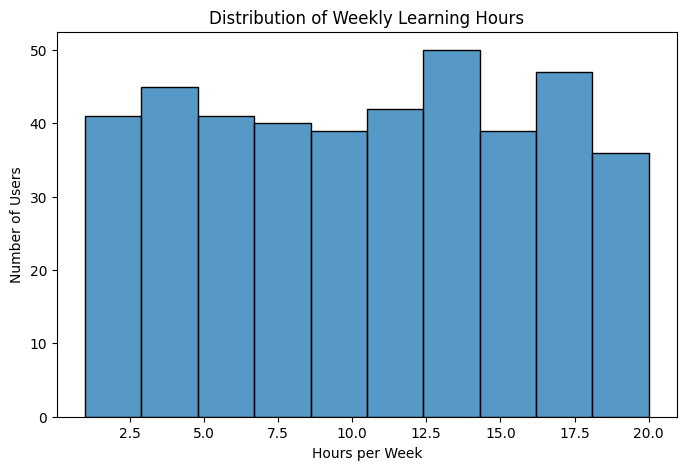

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="hours_per_week", bins=10)

plt.title("Distribution of Weekly Learning Hours")
plt.xlabel("Hours per Week")
plt.ylabel("Number of Users")

plt.show()

### Розподіл кількості годин навчання на тиждень

Гістограма показує, що кількість годин навчання на тиждень серед користувачів розподілена досить рівномірно.

Більшість користувачів витрачають приблизно від **5 до 15 годин на тиждень** на навчання, що можна вважати типовою інтенсивністю використання онлайн-платформ.

Водночас у вибірці присутні користувачі як з нижчим рівнем активності (1–4 години), так і з більш високою залученістю (понад 15 годин на тиждень).

Це свідчить про те, що користувачі мають **різні стилі навчання та рівні залученості**, що може бути пов’язано з їхніми цілями навчання, професійною діяльністю або доступністю часу.

---

Питання 6

Чи пов’язаний рівень завершення курсу із задоволеністю користувачів?

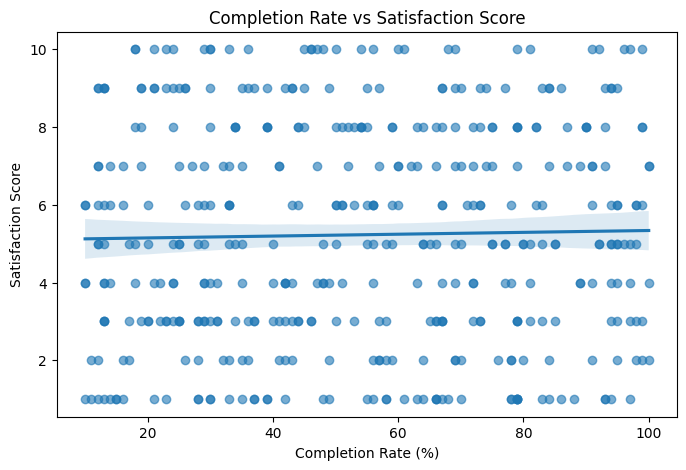

In [47]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="completion_rate_percent",
    y="satisfaction_score",
    scatter_kws={"alpha":0.6}
)

plt.title("Completion Rate vs Satisfaction Score")
plt.xlabel("Completion Rate (%)")
plt.ylabel("Satisfaction Score")

plt.show()

### Зв’язок між рівнем завершення курсу та задоволеністю користувачів

Точкова діаграма з лінією тренду показує, що між рівнем завершення курсу (`completion_rate_percent`) та задоволеністю користувачів (`satisfaction_score`) не спостерігається чіткої залежності.

Лінія тренду на графіку є майже горизонтальною, що свідчить про **дуже слабкий або відсутній лінійний зв’язок** між цими показниками.

Це означає, що користувачі можуть бути задоволені платформою навіть у випадку, якщо вони не завершують курс повністю. Так само користувачі, які проходять більшу частину курсу, не завжди демонструють значно вищий рівень задоволеності.

---

Питання 7

Чи відрізняється рівень задоволеності користувачів залежно від платформи навчання?

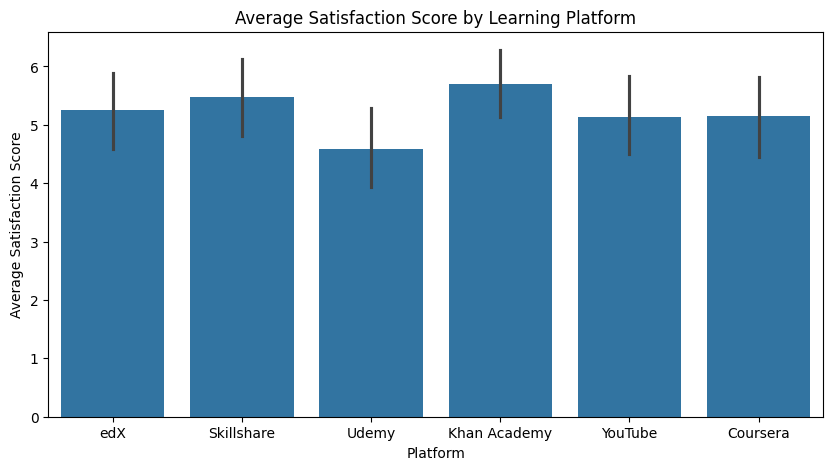

In [48]:
plt.figure(figsize=(10,5))

sns.barplot(data=df, x="primary_platform", y="satisfaction_score")

plt.title("Average Satisfaction Score by Learning Platform")
plt.xlabel("Platform")
plt.ylabel("Average Satisfaction Score")

plt.show()

### Рівень задоволеності користувачів залежно від платформи навчання

Аналіз показує, що рівень задоволеності користувачів дещо відрізняється залежно від платформи онлайн-навчання.

Найвищий середній показник задоволеності спостерігається на платформі **Khan Academy**, що може свідчити про позитивний користувацький досвід або високу якість навчального контенту.

Найнижчий показник задоволеності серед розглянутих платформ має **Udemy**.

Також бачимо, що різниця між більшістю платформ є відносно невеликою, що може означати, що загальний рівень задоволеності користувачів у сфері онлайн-навчання є досить подібним між різними платформами.

---

Питання 8

Який тип навчального контенту є найбільш популярним серед користувачів?

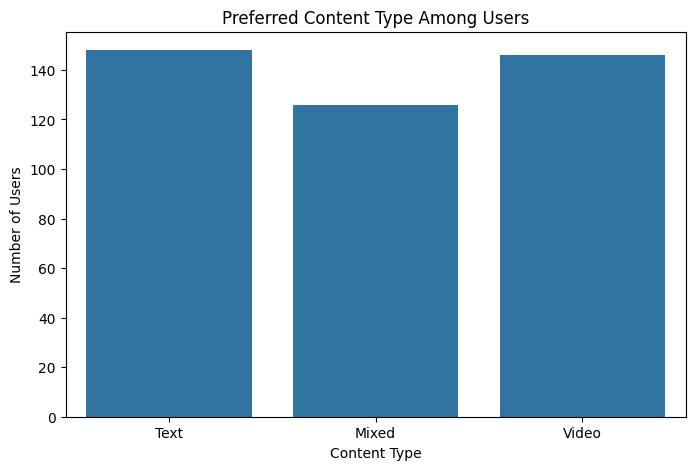

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="content_type_preference")

plt.title("Preferred Content Type Among Users")
plt.xlabel("Content Type")
plt.ylabel("Number of Users")

plt.show()

### Найбільш популярний тип навчального контенту

Аналіз показує, що користувачі віддають перевагу різним форматам навчального контенту, однак найбільш популярними є **текстовий контент (Text)** та **відео (Video)**.

Кількість користувачів, які віддають перевагу формату **Mixed**, є дещо меншою порівняно з іншими типами контенту.

Це може свідчити про те, що користувачі частіше обирають **чітко структурований формат навчання**, наприклад текстові матеріали або відеоуроки, замість комбінованого формату.

Отримані результати можуть бути корисними для платформ онлайн-навчання при плануванні формату майбутніх курсів та навчальних матеріалів.

---

## SQL Analysis

Для додаткового аналізу даних було використано SQL-запити.
SQL дозволяє ефективно агрегувати дані, виконувати групування та
отримувати аналітичні показники для різних сегментів користувачів.

In [50]:
import sqlite3
import pandas as pd

# створюємо тимчасову SQL базу
conn = sqlite3.connect(':memory:')

# завантажуємо наш датасет у SQL
df.to_sql('learning_data', conn, index=False)

print("Database successfully created")

Database successfully created


### 1. Середній рівень завершення курсів за платформами

Обчислюємо середній відсоток завершення курсів для кожної навчальної платформи.

In [51]:
query1 = """
SELECT
    primary_platform,
    ROUND(AVG(completion_rate_percent),2) AS avg_completion_rate
FROM learning_data
GROUP BY primary_platform
ORDER BY avg_completion_rate DESC
"""

pd.read_sql(query1, conn)

,primary_platform,avg_completion_rate
0,Udemy,56.99
1,Coursera,56.32
2,YouTube,54.95
3,Khan Academy,54.68
4,Skillshare,53.05
5,edX,47.55


### 2. Рівень задоволеності користувачів за віковими групами

За допомогою запиту обчислюємо середній рівень задоволеності користувачів для кожної вікової групи.

In [52]:
query2 = """
SELECT
    age_group,
    ROUND(AVG(satisfaction_score),2) AS avg_satisfaction
FROM learning_data
GROUP BY age_group
ORDER BY avg_satisfaction DESC
"""

pd.read_sql(query2, conn)

,age_group,avg_satisfaction
0,25-34,5.66
1,35-44,5.30
2,45+,5.29
3,Under 18,5.10
4,18-24,4.81


### 3. Найпопулярніший тип навчального контенту

Підраховуємо кількість користувачів для кожного типу навчального контенту.

In [53]:
query3 = """
SELECT
    content_type_preference,
    COUNT(*) AS users_count
FROM learning_data
GROUP BY content_type_preference
ORDER BY users_count DESC
"""

pd.read_sql(query3, conn)

,content_type_preference,users_count
0,Text,148
1,Video,146
2,Mixed,126


### 4. Середня кількість годин навчання залежно від мети навчання

Запит показує, скільки годин на тиждень у середньому витрачають користувачі на навчання залежно від мети навчання.

In [54]:
query4 = """
SELECT
    learning_purpose,
    ROUND(AVG(hours_per_week),2) AS avg_hours_per_week
FROM learning_data
GROUP BY learning_purpose
ORDER BY avg_hours_per_week DESC
"""

pd.read_sql(query4, conn)

,learning_purpose,avg_hours_per_week
0,Academic,11.15
1,Career Growth,10.41
2,Skill Upgrade,10.29
3,Hobby,10.06


### 5. Рейтинг платформ за рівнем завершення курсів

За допомогою функції RANK() визначаємо рейтинг платформ за середнім рівнем завершення курсів.

In [55]:
query5 = """
SELECT
    primary_platform,
    ROUND(AVG(completion_rate_percent),2) AS avg_completion_rate,
    RANK() OVER (
        ORDER BY AVG(completion_rate_percent) DESC
    ) AS platform_rank
FROM learning_data
GROUP BY primary_platform
"""

pd.read_sql(query5, conn)

,primary_platform,avg_completion_rate,platform_rank
0,Udemy,56.99,1
1,Coursera,56.32,2
2,YouTube,54.95,3
3,Khan Academy,54.68,4
4,Skillshare,53.05,5
5,edX,47.55,6


### Висновок

SQL-запити дозволили швидко агрегувати дані та отримати ключові показники
для різних сегментів користувачів. Результати SQL-аналізу підтвердили висновки,
отримані під час Python-аналізу та візуалізації даних.

---

## Додатковий аналіз у Google Sheets

Для розширення аналізу дані також були використані у Google Sheets https://docs.google.com/spreadsheets/d/1RAnk0U7oirevWl2Ykk5ZKjfaApIDEfsMvSdfyYhOZqY/edit?usp=sharing

У середовищі Google Sheets було створено зведені таблиці (Pivot Tables) для агрегування ключових показників, таких як:

- середній рівень завершення курсів за платформами
- середній рівень задоволеності користувачів за віковими групами
- середня кількість годин навчання залежно від мети навчання

На основі цих агрегованих даних було створено декілька візуалізацій, а також невелику KPI-панель, що відображає ключові метрики платформи:

- Average Completion Rate
- Average Satisfaction Score
- Average Weekly Learning Hours

Такий підхід дозволяє швидко оцінити загальний стан платформи та поведінку користувачів.

Нижче представлено приклад дашборду, створеного у Google Sheets.

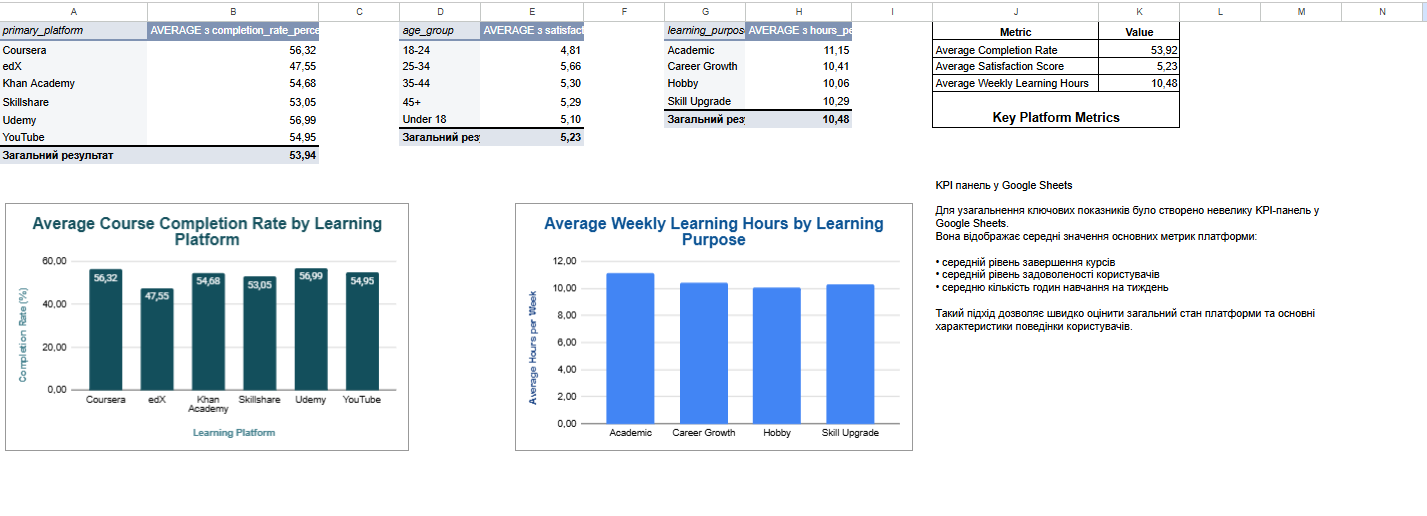

----

## Power BI Dashboard

Для візуалізації результатів аналізу було створено інтерактивний дашборд у Power BI.

Дашборд відображає ключові метрики:

- Average Completion Rate
- Average Weekly Learning Hours
- Average Satisfaction Score
- Total Users

Також дашборд містить інтерактивні фільтри, що дозволяють аналізувати дані
за віковими групами та платформами онлайн-навчання.

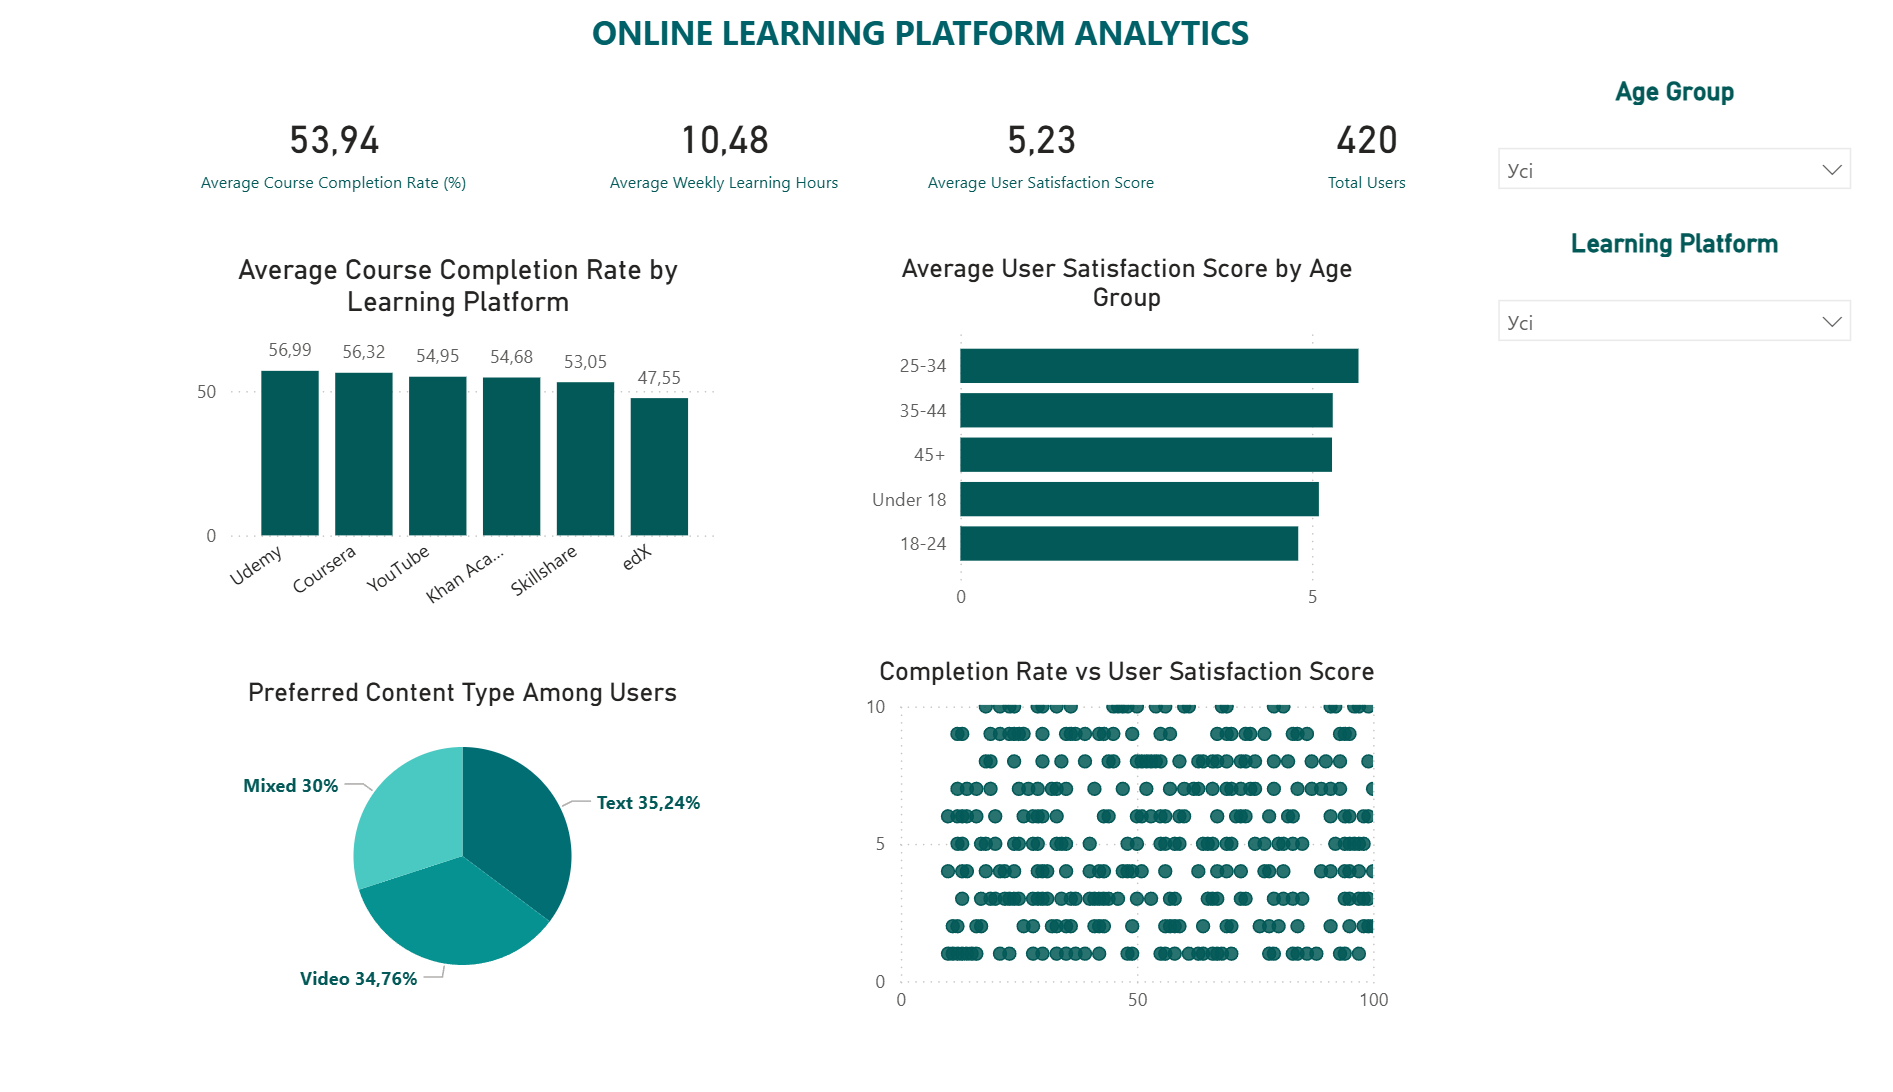

## Основні результати аналізу

Аналіз даних показує наступні ключові закономірності:

- рівень завершення курсів дещо відрізняється між навчальними платформами, але загалом знаходиться в межах **приблизно 47–57%**;

- найвищий середній рівень задоволеності спостерігається у віковій групі **25–34 років**;

- користувачі майже **рівномірно надають перевагу різним типам контенту** (`Text`, `Video`, `Mixed`);

- між **рівнем завершення курсу** (`completion_rate_percent`) та **рівнем задоволеності користувачів** (`satisfaction_score`) **не спостерігається сильного прямого зв’язку**.

---

## Machine Learning Model

Для додаткового аналізу було застосовано модель машинного навчання,
яка дозволяє дослідити можливість прогнозування рівня задоволеності користувачів
(`satisfaction_score`) на основі характеристик їхньої поведінки на платформі.

У якості моделі було використано **Linear Regression**, оскільки змінна
`satisfaction_score` є числовою.

У моделі були використані такі ознаки:

- completion_rate_percent
- hours_per_week

Модель була навчена на 80% даних та протестована на 20%.

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [57]:
X = df[[
    "completion_rate_percent",
    "hours_per_week"
]]

y = df["satisfaction_score"]

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [59]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [60]:
predictions = model.predict(X_test)

In [61]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.1947555902624236


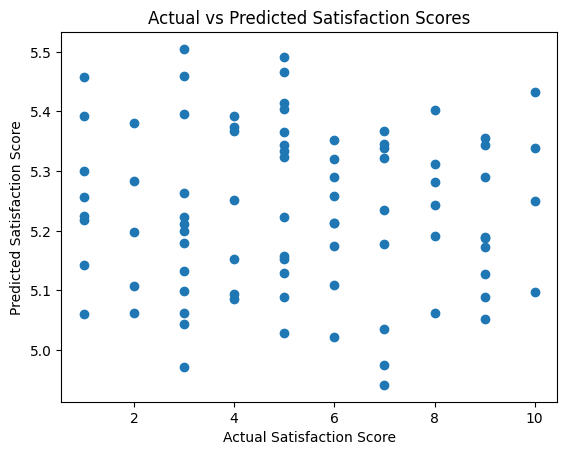

In [62]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Satisfaction Score")
plt.ylabel("Predicted Satisfaction Score")
plt.title("Actual vs Predicted Satisfaction Scores")

plt.show()

### Висновок щодо моделі

Було побудовано модель лінійної регресії для прогнозування рівня задоволеності користувачів.

Результати моделі показують, що змінні **completion rate** та **кількість годин навчання на тиждень**
мають певний вплив на рівень задоволеності користувачів.

Однак модель демонструє обмежену точність, що свідчить про те, що на задоволеність користувачів
можуть впливати й інші фактори, які не представлені у цьому датасеті.

---

## Загальні висновки та рекомендації

На основі проведеного аналізу даних за допомогою Python, SQL, Google Sheets, Power BI та базової моделі машинного навчання було отримано декілька важливих інсайтів щодо поведінки користувачів онлайн-платформ навчання.

### Основні інсайти

1. **Рівень завершення курсів відрізняється між платформами.**  
   Аналіз показав, що деякі платформи демонструють вищий середній рівень завершення курсів. Це може бути пов’язано з якістю навчальних матеріалів, структурою курсів або зручністю користування платформою.

2. **Найвищий рівень задоволеності спостерігається серед користувачів вікової групи 25–34 років.**  
   Це може свідчити про те, що онлайн-навчальні платформи особливо добре відповідають потребам користувачів цієї вікової категорії.

3. **Тип навчального контенту розподілений досить рівномірно.**  
   Користувачі використовують як відеоконтент, так і текстові матеріали або змішаний формат навчання. Це свідчить про важливість підтримки різних форматів подачі навчального матеріалу.

4. **Кількість годин навчання на тиждень пов’язана з рівнем залученості користувачів.**  
   Користувачі, які витрачають більше часу на навчання, зазвичай демонструють вищий рівень завершення курсів.

5. **Зв’язок між рівнем завершення курсів та рівнем зхадоволеністю платформи є відносно слабким.**  
   Це означає, що навіть користувачі з високим рівнем завершення курсів не завжди мають високий рівень задоволеності платформою.

6. **Модель машинного навчання показала, що рівень завершення курсів та години навчання можуть впливати на рівень задоволеності користувачів, проте цих змінних недостатньо для точного прогнозування рівня задоволеності платформою.**

### Рекомендації

На основі отриманих результатів можна сформулювати декілька рекомендацій для онлайн-платформ навчання:

- **Оптимізувати структуру курсів** на платформах з нижчим рівнем завершення курсів.
- **Розвивати персоналізацію навчального контенту** для різних вікових груп користувачів.
- **Підтримувати різні формати навчального контенту** (відео, текст, змішаний формат), оскільки користувачі мають різні вподобання.
- **Заохочувати регулярну навчальну активність**, оскільки більша кількість годин навчання пов’язана з вищим рівнем завершення курсів.
- **Проводити додаткові дослідження факторів задоволеності користувачів**, щоб краще зрозуміти, які елементи платформи впливають на їхній досвід навчання.